In [39]:
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely import wkt
from shapely.geometry.base import BaseGeometry

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

In [40]:
BASE_IN = Path("/data/shared/fsibilla/DATA_PROCESSING/yem_mvam/yem")
BASE_OUT = Path("/data/shared/fsibilla/DATA_PROCESSING/yem_mvam")

MVAM_PATH = BASE_IN / "Obs_YEMCln_20260212.csv"
ADM1_WSCORE_PATH = BASE_IN / "adm1_mics_wscore.csv"
CLIMATE_MEDIANS_PATH = BASE_OUT / "climate_medians.csv"

FINAL_CSV_PATH = BASE_OUT / "full_simple_manual.csv"

print("MVAM exists:", MVAM_PATH.exists())
print("ADM1 wscore exists:", ADM1_WSCORE_PATH.exists())
print("Climate/admin exists:", CLIMATE_MEDIANS_PATH.exists())

MVAM exists: True
ADM1 wscore exists: True
Climate/admin exists: True


In [41]:
def normalize_name(x):
    """
    Simple name normalization:
    - lowercase
    - remove accents
    - remove apostrophes
    - replace punctuation with spaces
    - collapse spaces
    """
    if pd.isna(x):
        return ""

    s = str(x).strip().lower()

    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))

    s = (
        s.replace("’", "'")
         .replace("‘", "'")
         .replace("`", "'")
         .replace("´", "'")
         .replace("ʿ", "'")
         .replace("ʻ", "'")
    )

    s = s.replace("'", "")
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()

    return s


def parse_geometry(x):
    """
    Convert WKT text to shapely geometry.
    If already geometry, keep it.
    If impossible, return None.
    """
    if isinstance(x, BaseGeometry):
        return x

    if pd.isna(x):
        return None

    if isinstance(x, str):
        try:
            return wkt.loads(x)
        except Exception:
            return None

    return None


def show_shape(name, data):
    print(f"{name}: {data.shape[0]} rows, {data.shape[1]} columns")

In [42]:
df_raw = pd.read_csv(MVAM_PATH)
df = df_raw.copy()

show_shape("Survey df", df)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Survey df: 54707 rows, 17 columns

Columns:
['ObsID', 'RspID', 'ObsDate', 'BirthYear', 'DM_HHAge', 'HHSize_90days', 'ADM1_NAME', 'ADM1_CODE', 'ADM2_NAME', 'ADM2_CODE', 'FCS', 'rCSI', 'HHExpF_MNCRD_7D', 'HHExpF_GiftAid_7D', 'HHExpF_Own_7D', 'HHExpNF_MNCRD_1M', 'HHExpNF_GiftAid_1M']


,ObsID,RspID,ObsDate,BirthYear,DM_HHAge,HHSize_90days,ADM1_NAME,ADM1_CODE,ADM2_NAME,ADM2_CODE,FCS,rCSI,HHExpF_MNCRD_7D,HHExpF_GiftAid_7D,HHExpF_Own_7D,HHExpNF_MNCRD_1M,HHExpNF_GiftAid_1M
0,6688817,CTC120625A2823,2025-08-01 00:00:00.000,28,28.0,8,Ibb,3419,Far' Al Odayn,32887.0,21.0,7.0,25000.0,0.0,0.0,4000.0,0.0
1,6686152,CTC150824A4683,2025-08-01 00:00:00.000,35,35.0,7,Ibb,3419,Ar Radmah,32879.0,33.0,14.0,21000.0,0.0,20000.0,8000.0,0.0
2,6687988,CTC010825A75,2025-08-01 00:00:00.000,50,50.0,12,Sana'a,3423,Khawlan,32950.0,56.0,21.0,30000.0,6000.0,0.0,0.0,6500.0
3,6689386,CTC170325A5664,2025-08-01 00:00:00.000,65,65.0,7,Ibb,3419,Ash Sha'ir,32884.0,28.0,12.0,8000.0,0.0,0.0,12000.0,0.0
4,6689572,CTC121224A2846,2025-08-01 00:00:00.000,35,35.0,9,Ibb,3419,Ash Sha'ir,32884.0,18.5,16.0,5000.0,0.0,5000.0,60000.0,0.0


In [43]:
food_exp = (
    df["HHExpF_MNCRD_7D"] +
    df["HHExpF_GiftAid_7D"] +
    df["HHExpF_Own_7D"]
)

nonfood_exp = (
    df["HHExpNF_MNCRD_1M"] +
    df["HHExpNF_GiftAid_1M"]
)

hh_size = df["HHSize_90days"].replace(0, np.nan)

df["log_exp_pp"] = np.log((food_exp + nonfood_exp) / hh_size)
df["FES_eqiv"] = food_exp / nonfood_exp.replace(0, np.nan)

if "ObsDate" in df.columns:
    df["ObsDate"] = pd.to_datetime(df["ObsDate"], errors="coerce")
    print("ObsDate range:", df["ObsDate"].min(), "to", df["ObsDate"].max())

display(df[["ObsID", "ADM1_NAME", "ADM2_NAME", "log_exp_pp", "FES_eqiv", "rCSI", "FCS"]].head())

ObsDate range: 2025-08-01 00:00:00 to 2026-01-31 00:00:00


,ObsID,ADM1_NAME,ADM2_NAME,log_exp_pp,FES_eqiv,rCSI,FCS
0,6688817,Ibb,Far' Al Odayn,8.195610,6.250000,7.0,21.0
1,6686152,Ibb,Ar Radmah,8.853665,5.125000,14.0,33.0
2,6687988,Sana'a,Khawlan,8.172353,5.538462,21.0,56.0
3,6689386,Ibb,Ash Sha'ir,7.957577,0.666667,12.0,28.0
4,6689572,Ibb,Ash Sha'ir,8.959026,0.166667,16.0,18.5


In [44]:
df["adm1_key"] = df["ADM1_NAME"].apply(normalize_name)
df["adm2_key"] = df["ADM2_NAME"].apply(normalize_name)

survey_pairs = (
    df[["ADM1_NAME", "ADM2_NAME", "adm1_key", "adm2_key"]]
    .drop_duplicates()
    .sort_values(["adm1_key", "adm2_key"])
    .reset_index(drop=True)
)

print("Unique survey ADM1/ADM2 pairs:", len(survey_pairs))
display(survey_pairs)

Unique survey ADM1/ADM2 pairs: 332


,ADM1_NAME,ADM2_NAME,adm1_key,adm2_key
0,Abyan,Ahwar,abyan,ahwar
1,Abyan,Al Mahfad,abyan,al mahfad
2,Abyan,Al Wadi',abyan,al wadi
3,Abyan,Jayshan,abyan,jayshan
4,Abyan,Khanfar,abyan,khanfar
...,...,...,...,...
327,Ta'iz,Sabir Al Mawadim,taiz,sabir al mawadim
328,Ta'iz,Salah,taiz,salah
329,Ta'iz,Sami',taiz,sami
330,Ta'iz,Shar'ab Ar Rawnah,taiz,sharab ar rawnah


In [45]:
adm1_wscore_raw = pd.read_csv(ADM1_WSCORE_PATH)
adm1_wscore = adm1_wscore_raw.copy()

show_shape("ADM1 wscore", adm1_wscore)

print("\nColumns:")
print(adm1_wscore.columns.tolist())

display(adm1_wscore.head())

ADM1 wscore: 22 rows, 2 columns

Columns:
['HH7', 'wscore']


,HH7,wscore
0,Abyan,0.436440
1,Aden,1.146115
2,Al Bayda,0.094529
3,Al Dhale'e,-0.205586
4,Al Hudaydah,-0.155019


In [46]:
# Look at the columns printed above.
# In the old notebook, the likely ADM1 name column was "HH7".

adm1_wscore_name_col = "HH7"

adm1_wscore["adm1_key"] = adm1_wscore[adm1_wscore_name_col].apply(normalize_name)

adm1_wscore_lookup = (
    adm1_wscore[["adm1_key", "wscore"]]
    .groupby("adm1_key", as_index=False)
    .mean()
    .rename(columns={"wscore": "wscore_1"})
)

print("ADM1 wscore lookup:")
display(adm1_wscore_lookup)

ADM1 wscore lookup:


,adm1_key,wscore_1
0,abyan,0.436440
1,aden,1.146115
2,al bayda,0.094529
3,al dhalee,-0.205586
4,al hudaydah,-0.155019
5,al jawf,-0.951820
6,al maharah,0.665844
7,al mahwit,-0.586501
8,amran,-0.348794
9,dhamar,-0.398291


In [47]:
before = len(df)

df = df.merge(
    adm1_wscore_lookup,
    on="adm1_key",
    how="left",
    indicator="wscore_merge_status"
)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("\nMerge status:")
print(df["wscore_merge_status"].value_counts())

display(
    df[["ADM1_NAME", "adm1_key", "wscore_1", "wscore_merge_status"]]
    .drop_duplicates()
    .sort_values("adm1_key")
)

Rows before: 54707
Rows after: 54707

Merge status:
wscore_merge_status
both          38309
left_only     16398
right_only        0
Name: count, dtype: int64


,ADM1_NAME,adm1_key,wscore_1,wscore_merge_status
7,Abyan,abyan,0.436440,both
131,Ad Dali',ad dali,NaN,left_only
74,Aden,aden,1.146115,both
84,Al Bayda,al bayda,0.094529,both
15,Al Hodeidah,al hodeidah,NaN,left_only
24,Al Jawf,al jawf,-0.951820,both
136,Al Maharah,al maharah,0.665844,both
229,Al Mahwit,al mahwit,-0.586501,both
110,Amran,amran,-0.348794,both
97,Dhamar,dhamar,-0.398291,both


In [48]:
unmatched_wscore = (
    df[df["wscore_merge_status"] == "left_only"]
    [["ADM1_NAME", "adm1_key"]]
    .drop_duplicates()
    .sort_values("adm1_key")
    .reset_index(drop=True)
)

print("Unmatched ADM1 keys:", len(unmatched_wscore))
display(unmatched_wscore)

print("\nAvailable ADM1 keys in wscore file:")
display(adm1_wscore_lookup.sort_values("adm1_key"))

Unmatched ADM1 keys: 5


,ADM1_NAME,adm1_key
0,Ad Dali',ad dali
1,Al Hodeidah,al hodeidah
2,Hadramawt,hadramawt
3,Sa'dah,sadah
4,Ta'iz,taiz



Available ADM1 keys in wscore file:


,adm1_key,wscore_1
0,abyan,0.436440
1,aden,1.146115
2,al bayda,0.094529
3,al dhalee,-0.205586
4,al hudaydah,-0.155019
5,al jawf,-0.951820
6,al maharah,0.665844
7,al mahwit,-0.586501
8,amran,-0.348794
9,dhamar,-0.398291


In [49]:
# These are the names as they appear in the wscore file → survey names
wscore_to_survey_fixes = {
   "al hudaydah": "al hodeidah",
   "al dhalee": "ad dali",
   "hadramaut": "hadramawt",
   "saada": "sadah",
   "taizz": "taiz",
}

adm1_wscore_lookup["adm1_key_original"] = adm1_wscore_lookup["adm1_key"]
adm1_wscore_lookup["adm1_key"] = adm1_wscore_lookup["adm1_key_original"]

for old_key, new_key in wscore_to_survey_fixes.items():
    mask = adm1_wscore_lookup["adm1_key_original"] == old_key
    print(old_key, "→", new_key, "| rows changed:", mask.sum())
    adm1_wscore_lookup.loc[mask, "adm1_key"] = new_key

al hudaydah → al hodeidah | rows changed: 1
al dhalee → ad dali | rows changed: 1
hadramaut → hadramawt | rows changed: 1
saada → sadah | rows changed: 1
taizz → taiz | rows changed: 1


In [50]:
df = df.drop(columns=["wscore_1", "wscore_merge_status"], errors="ignore")

before = len(df)

df = df.merge(
    adm1_wscore_lookup,
    on="adm1_key",
    how="left",
    indicator="wscore_merge_status"
)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("\nMerge status:")
print(df["wscore_merge_status"].value_counts())

display(
    df[["ADM1_NAME", "adm1_key", "wscore_1", "wscore_merge_status"]]
    .drop_duplicates()
    .sort_values("adm1_key")
)

Rows before: 54707
Rows after: 54707

Merge status:
wscore_merge_status
both          54707
left_only         0
right_only        0
Name: count, dtype: int64


,ADM1_NAME,adm1_key,wscore_1,wscore_merge_status
7,Abyan,abyan,0.436440,both
131,Ad Dali',ad dali,-0.205586,both
74,Aden,aden,1.146115,both
84,Al Bayda,al bayda,0.094529,both
15,Al Hodeidah,al hodeidah,-0.155019,both
24,Al Jawf,al jawf,-0.951820,both
136,Al Maharah,al maharah,0.665844,both
229,Al Mahwit,al mahwit,-0.586501,both
110,Amran,amran,-0.348794,both
97,Dhamar,dhamar,-0.398291,both


In [51]:
# Cell 14 — Load climate/admin file

climate_raw = pd.read_csv(CLIMATE_MEDIANS_PATH)
climate = climate_raw.copy()

show_shape("Climate/admin", climate)

print("\nClimate columns:")
print(climate.columns.tolist())

display(climate.head())

Climate/admin: 318 rows, 12 columns

Climate columns:
['adm1Name', 'adm1Code', 'adm2Name', 'adm2Code', 'rfh_avg_2', 'r3q_2', 'vim_avg_2', 'rfh_avg_1', 'r3q_1', 'vim_avg_1', 'adm1Geometry', 'adm2Geometry']


,adm1Name,adm1Code,adm2Name,adm2Code,rfh_avg_2,r3q_2,vim_avg_2,rfh_avg_1,r3q_1,vim_avg_1,adm1Geometry,adm2Geometry
0,Abyan,3407,Ahwar,32692,1.92265,105.42765,0.07880,2.2462,107.7695,0.1259,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((47.1607 13.9674, 46.9448 13.9542, 46..."
1,Abyan,3407,Al Mahfad,32693,2.53050,108.65180,0.10935,2.2462,107.7695,0.1259,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((47.1607 13.9674, 47.0923 14.0838, 46..."
2,Abyan,3407,Al Wade'a,32694,2.27970,109.69145,0.10950,2.2462,107.7695,0.1259,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((46.0297 13.8385, 45.8759 13.7454, 45..."
3,Abyan,3407,Jayshan,32695,2.21475,103.47885,0.12835,2.2462,107.7695,0.1259,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((46.2872 14.0803, 46.3411 14.201, 46...."
4,Abyan,3407,Khanfir,32696,2.00910,108.45420,0.10590,2.2462,107.7695,0.1259,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((45.9258 13.5902, 45.8106 13.4848, 45..."


In [52]:
# Cell 15 — Inspect survey columns for admin codes

print("Survey columns:")
print(df.columns.tolist())

possible_survey_code_cols = [
    c for c in df.columns
    if "code" in c.lower() or "pcode" in c.lower() or "adm" in c.lower()
]

print("\nPossible survey admin/code columns:")
print(possible_survey_code_cols)

display(df[possible_survey_code_cols].head())

Survey columns:
['ObsID', 'RspID', 'ObsDate', 'BirthYear', 'DM_HHAge', 'HHSize_90days', 'ADM1_NAME', 'ADM1_CODE', 'ADM2_NAME', 'ADM2_CODE', 'FCS', 'rCSI', 'HHExpF_MNCRD_7D', 'HHExpF_GiftAid_7D', 'HHExpF_Own_7D', 'HHExpNF_MNCRD_1M', 'HHExpNF_GiftAid_1M', 'log_exp_pp', 'FES_eqiv', 'adm1_key', 'adm2_key', 'wscore_1', 'adm1_key_original', 'wscore_merge_status']

Possible survey admin/code columns:
['ADM1_NAME', 'ADM1_CODE', 'ADM2_NAME', 'ADM2_CODE', 'adm1_key', 'adm2_key', 'adm1_key_original']


,ADM1_NAME,ADM1_CODE,ADM2_NAME,ADM2_CODE,adm1_key,adm2_key,adm1_key_original
0,Ibb,3419,Far' Al Odayn,32887.0,ibb,far al odayn,ibb
1,Ibb,3419,Ar Radmah,32879.0,ibb,ar radmah,ibb
2,Sana'a,3423,Khawlan,32950.0,sanaa,khawlan,sanaa
3,Ibb,3419,Ash Sha'ir,32884.0,ibb,ash shair,ibb
4,Ibb,3419,Ash Sha'ir,32884.0,ibb,ash shair,ibb


In [53]:
# Cell 16 — Inspect climate columns for admin codes

possible_climate_code_cols = [
    c for c in climate.columns
    if "code" in c.lower() or "pcode" in c.lower() or "adm" in c.lower()
]

print("Possible climate admin/code columns:")
print(possible_climate_code_cols)

display(climate[possible_climate_code_cols].head())

Possible climate admin/code columns:
['adm1Name', 'adm1Code', 'adm2Name', 'adm2Code', 'adm1Geometry', 'adm2Geometry']


,adm1Name,adm1Code,adm2Name,adm2Code,adm1Geometry,adm2Geometry
0,Abyan,3407,Ahwar,32692,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((47.1607 13.9674, 46.9448 13.9542, 46..."
1,Abyan,3407,Al Mahfad,32693,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((47.1607 13.9674, 47.0923 14.0838, 46..."
2,Abyan,3407,Al Wade'a,32694,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((46.0297 13.8385, 45.8759 13.7454, 45..."
3,Abyan,3407,Jayshan,32695,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((46.2872 14.0803, 46.3411 14.201, 46...."
4,Abyan,3407,Khanfir,32696,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((45.9258 13.5902, 45.8106 13.4848, 45..."


In [54]:
# Cell 17 — Choose code columns manually
#
# These are likely names, but verify them using Cells 15 and 16.

survey_adm1_code_col = "ADM1_CODE"
survey_adm2_code_col = "ADM2_CODE"

climate_adm1_code_col = "adm1Code"
climate_adm2_code_col = "adm2Code"

print("Survey ADM1 code column:", survey_adm1_code_col)
print("Survey ADM2 code column:", survey_adm2_code_col)
print("Climate ADM1 code column:", climate_adm1_code_col)
print("Climate ADM2 code column:", climate_adm2_code_col)

print("\nSurvey code examples:")
display(df[[survey_adm1_code_col, survey_adm2_code_col, "ADM1_NAME", "ADM2_NAME"]].head())

print("\nClimate code examples:")
display(climate[[climate_adm1_code_col, climate_adm2_code_col]].head())

Survey ADM1 code column: ADM1_CODE
Survey ADM2 code column: ADM2_CODE
Climate ADM1 code column: adm1Code
Climate ADM2 code column: adm2Code

Survey code examples:


,ADM1_CODE,ADM2_CODE,ADM1_NAME,ADM2_NAME
0,3419,32887.0,Ibb,Far' Al Odayn
1,3419,32879.0,Ibb,Ar Radmah
2,3423,32950.0,Sana'a,Khawlan
3,3419,32884.0,Ibb,Ash Sha'ir
4,3419,32884.0,Ibb,Ash Sha'ir



Climate code examples:


,adm1Code,adm2Code
0,3407,32692
1,3407,32693
2,3407,32694
3,3407,32695
4,3407,32696


In [55]:
# Cell 18 — Create clean code keys

def clean_code(x):
    """
    Make admin codes comparable:
    - convert to string
    - remove spaces
    - remove trailing .0 if read as float
    - uppercase
    """
    if pd.isna(x):
        return ""

    s = str(x).strip()
    s = re.sub(r"\.0$", "", s)
    s = s.replace(" ", "")
    s = s.upper()

    return s


df["adm1_code_key"] = df[survey_adm1_code_col].apply(clean_code)
df["adm2_code_key"] = df[survey_adm2_code_col].apply(clean_code)

climate["adm1_code_key"] = climate[climate_adm1_code_col].apply(clean_code)
climate["adm2_code_key"] = climate[climate_adm2_code_col].apply(clean_code)

print("Survey code keys:")
display(
    df[[survey_adm1_code_col, survey_adm2_code_col, "adm1_code_key", "adm2_code_key", "ADM1_NAME", "ADM2_NAME"]]
    .drop_duplicates()
    .head(30)
)

print("\nClimate code keys:")
display(
    climate[[climate_adm1_code_col, climate_adm2_code_col, "adm1_code_key", "adm2_code_key"]]
    .drop_duplicates()
    .head(30)
)

Survey code keys:


,ADM1_CODE,ADM2_CODE,adm1_code_key,adm2_code_key,ADM1_NAME,ADM2_NAME
0,3419,32887.0,3419,32887,Ibb,Far' Al Odayn
1,3419,32879.0,3419,32879,Ibb,Ar Radmah
2,3423,32950.0,3423,32950,Sana'a,Khawlan
3,3419,32884.0,3419,32884,Ibb,Ash Sha'ir
5,144969,999529.0,144969,999529,Sana'a City,Bani Al Harith
6,3419,144974.0,3419,144974,Ibb,Adh Dhihar
7,3407,32692.0,3407,32692,Abyan,Ahwar
8,3419,32881.0,3419,32881,Ibb,As Sabrah
10,3422,32927.0,3422,32927,Sa'dah,Qatabir
12,3419,32878.0,3419,32878,Ibb,Al Qafr



Climate code keys:


,adm1Code,adm2Code,adm1_code_key,adm2_code_key
0,3407,32692,3407,32692
1,3407,32693,3407,32693
2,3407,32694,3407,32694
3,3407,32695,3407,32695
4,3407,32696,3407,32696
5,3407,32697,3407,32697
6,3407,32698,3407,32698
7,3407,32699,3407,32699
8,3407,32701,3407,32701
9,3407,32700,3407,32700


In [56]:
# Cell 19 — Rename climate admin columns clearly

clim_adm1_name_col = "adm1Name"
clim_adm2_name_col = "adm2Name"
clim_adm1_code_col = climate_adm1_code_col
clim_adm2_code_col = climate_adm2_code_col

climate = climate.rename(columns={
    clim_adm1_name_col: "clim_adm1name",
    clim_adm2_name_col: "clim_adm2name",
    clim_adm1_code_col: "clim_adm1code",
    clim_adm2_code_col: "clim_adm2code",
})

display(
    climate[
        [
            "clim_adm1name",
            "clim_adm2name",
            "clim_adm1code",
            "clim_adm2code",
            "adm1_code_key",
            "adm2_code_key",
        ]
    ]
    .drop_duplicates()
    .head(50)
)

,clim_adm1name,clim_adm2name,clim_adm1code,clim_adm2code,adm1_code_key,adm2_code_key
0,Abyan,Ahwar,3407,32692,3407,32692
1,Abyan,Al Mahfad,3407,32693,3407,32693
2,Abyan,Al Wade'a,3407,32694,3407,32694
3,Abyan,Jayshan,3407,32695,3407,32695
4,Abyan,Khanfir,3407,32696,3407,32696
5,Abyan,Lawdar,3407,32697,3407,32697
6,Abyan,Mudiyah,3407,32698,3407,32698
7,Abyan,Rasad,3407,32699,3407,32699
8,Abyan,Sarar,3407,32701,3407,32701
9,Abyan,Sibah,3407,32700,3407,32700


In [57]:
# Cell 20 — Parse geometry columns if present

if "adm1Geometry" in climate.columns:
    climate["adm1geometry"] = climate["adm1Geometry"].apply(parse_geometry)
elif "adm1geometry" in climate.columns:
    climate["adm1geometry"] = climate["adm1geometry"].apply(parse_geometry)
else:
    climate["adm1geometry"] = None
    print("No ADM1 geometry column found.")

if "adm2Geometry" in climate.columns:
    climate["adm2geometry"] = climate["adm2Geometry"].apply(parse_geometry)
elif "adm2geometry" in climate.columns:
    climate["adm2geometry"] = climate["adm2geometry"].apply(parse_geometry)
else:
    climate["adm2geometry"] = None
    print("No ADM2 geometry column found.")

In [58]:
# Cell 21 — Select climate columns to attach

possible_climate_cols = [
    "rfh_avg_2",
    "r3q_2",
    "vim_avg_2",
    "rfh_avg_1",
    "r3q_1",
    "vim_avg_1",
]

available_climate_cols = [c for c in possible_climate_cols if c in climate.columns]

climate_lookup_cols = [
    "adm1_code_key",
    "adm2_code_key",
    "clim_adm1name",
    "clim_adm1code",
    "clim_adm2name",
    "clim_adm2code",
    "adm1geometry",
    "adm2geometry",
] + available_climate_cols

climate_lookup = climate[climate_lookup_cols].copy()

print("Climate columns that will be attached:")
print(climate_lookup_cols)

display(climate_lookup.head())

Climate columns that will be attached:
['adm1_code_key', 'adm2_code_key', 'clim_adm1name', 'clim_adm1code', 'clim_adm2name', 'clim_adm2code', 'adm1geometry', 'adm2geometry', 'rfh_avg_2', 'r3q_2', 'vim_avg_2', 'rfh_avg_1', 'r3q_1', 'vim_avg_1']


,adm1_code_key,adm2_code_key,clim_adm1name,clim_adm1code,clim_adm2name,clim_adm2code,adm1geometry,adm2geometry,rfh_avg_2,r3q_2,vim_avg_2,rfh_avg_1,r3q_1,vim_avg_1
0,3407,32692,Abyan,3407,Ahwar,32692,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((47.1607 13.9674, 46.9448 13.9542, 46...",1.92265,105.42765,0.07880,2.2462,107.7695,0.1259
1,3407,32693,Abyan,3407,Al Mahfad,32693,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((47.1607 13.9674, 47.0923 14.0838, 46...",2.53050,108.65180,0.10935,2.2462,107.7695,0.1259
2,3407,32694,Abyan,3407,Al Wade'a,32694,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((46.0297 13.8385, 45.8759 13.7454, 45...",2.27970,109.69145,0.10950,2.2462,107.7695,0.1259
3,3407,32695,Abyan,3407,Jayshan,32695,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((46.2872 14.0803, 46.3411 14.201, 46....",2.21475,103.47885,0.12835,2.2462,107.7695,0.1259
4,3407,32696,Abyan,3407,Khanfir,32696,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...","POLYGON ((45.9258 13.5902, 45.8106 13.4848, 45...",2.00910,108.45420,0.10590,2.2462,107.7695,0.1259


In [59]:
# Cell 22 — Check duplicated climate ADM1/ADM2 codes

climate_code_counts = (
    climate_lookup
    .value_counts(["adm1_code_key", "adm2_code_key"])
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

duplicated_climate_codes = climate_code_counts[climate_code_counts["n"] > 1]

print("Duplicated climate ADM1/ADM2 code pairs:", len(duplicated_climate_codes))

display(duplicated_climate_codes)

Duplicated climate ADM1/ADM2 code pairs: 0


,adm1_code_key,adm2_code_key,n


In [60]:
# Cell 23 — Keep one climate row per ADM1/ADM2 code pair

climate_lookup = (
    climate_lookup
    .drop_duplicates(subset=["adm1_code_key", "adm2_code_key"])
    .copy()
)

print("Climate lookup rows after deduplication:", len(climate_lookup))

Climate lookup rows after deduplication: 318


In [61]:
# Cell 24 — First exact code merge

before = len(df)

df_code_merge = df.merge(
    climate_lookup,
    on=["adm1_code_key", "adm2_code_key"],
    how="left",
    indicator="climate_code_merge_status"
)

after = len(df_code_merge)

print("Rows before:", before)
print("Rows after:", after)

if before != after:
    print("WARNING: row count changed!")

print("\nClimate code merge status:")
print(df_code_merge["climate_code_merge_status"].value_counts())

display(
    df_code_merge[
        [
            "ADM1_NAME",
            "ADM2_NAME",
            survey_adm1_code_col,
            survey_adm2_code_col,
            "adm1_code_key",
            "adm2_code_key",
            "clim_adm1name",
            "clim_adm2name",
            "climate_code_merge_status",
        ]
    ]
    .head(50)
)

Rows before: 54707
Rows after: 54707

Climate code merge status:
climate_code_merge_status
both          52075
left_only      2632
right_only        0
Name: count, dtype: int64


,ADM1_NAME,ADM2_NAME,ADM1_CODE,ADM2_CODE,adm1_code_key,adm2_code_key,clim_adm1name,clim_adm2name,climate_code_merge_status
0,Ibb,Far' Al Odayn,3419,32887.0,3419,32887,Ibb,Far Al Udayn,both
1,Ibb,Ar Radmah,3419,32879.0,3419,32879,Ibb,Ar Radmah,both
2,Sana'a,Khawlan,3423,32950.0,3423,32950,Sana'a,Khwlan,both
3,Ibb,Ash Sha'ir,3419,32884.0,3419,32884,Ibb,Ash Sha'ir,both
4,Ibb,Ash Sha'ir,3419,32884.0,3419,32884,Ibb,Ash Sha'ir,both
5,Sana'a City,Bani Al Harith,144969,999529.0,144969,999529,Amanat Al Asimah,Bani Al Harith,both
6,Ibb,Adh Dhihar,3419,144974.0,3419,144974,Ibb,Al Dhihar,both
7,Abyan,Ahwar,3407,32692.0,3407,32692,Abyan,Ahwar,both
8,Ibb,As Sabrah,3419,32881.0,3419,32881,Ibb,As Sabrah,both
9,Ibb,Ar Radmah,3419,32879.0,3419,32879,Ibb,Ar Radmah,both


In [62]:
# Cell 25 — Show unmatched survey code pairs

unmatched_code_pairs = (
    df_code_merge[df_code_merge["climate_code_merge_status"] == "left_only"]
    [
        [
            "ADM1_NAME",
            "ADM2_NAME",
            survey_adm1_code_col,
            survey_adm2_code_col,
            "adm1_code_key",
            "adm2_code_key",
        ]
    ]
    .drop_duplicates()
    .sort_values(["adm1_code_key", "adm2_code_key"])
    .reset_index(drop=True)
)

print("Unmatched survey ADM1/ADM2 code pairs:", len(unmatched_code_pairs))

display(unmatched_code_pairs)

Unmatched survey ADM1/ADM2 code pairs: 15


,ADM1_NAME,ADM2_NAME,ADM1_CODE,ADM2_CODE,adm1_code_key,adm2_code_key
0,Sana'a City,Al Wehdah,144969,144978.0,144969,144978
1,Sana'a City,As Safiyah,144969,144980.0,144969,144980
2,Sana'a City,At Tahrir,144969,144981.0,144969,144981
3,Sana'a City,Ath Thawrah,144969,144982.0,144969,144982
4,Sana'a City,Azaal,144969,144983.0,144969,144983
5,Sana'a City,Old City,144969,144985.0,144969,144985
6,Aden,Al Mansurah,3409,145021.0,3409,145021
7,Aden,Al Mu'alla,3409,145022.0,3409,145022
8,Aden,At Tawahi,3409,145024.0,3409,145024
9,Al Hodeidah,Al Mina,3411,145009.0,3411,145009


In [63]:
# Cell 26 — Accept code merge and inspect unmatched rows

df = df_code_merge.copy()

print("Rows:", len(df))
print("\nCode merge status:")
print(df["climate_code_merge_status"].value_counts())

unmatched_code_pairs = (
    df[df["climate_code_merge_status"] == "left_only"]
    [
        [
            "ADM1_NAME",
            "ADM2_NAME",
            survey_adm1_code_col,
            survey_adm2_code_col,
            "adm1_code_key",
            "adm2_code_key",
        ]
    ]
    .drop_duplicates()
    .sort_values(["adm1_code_key", "adm2_code_key"])
    .reset_index(drop=True)
)

print("\nUnmatched ADM2 code pairs:", len(unmatched_code_pairs))
display(unmatched_code_pairs)

Rows: 54707

Code merge status:
climate_code_merge_status
both          52075
left_only      2632
right_only        0
Name: count, dtype: int64

Unmatched ADM2 code pairs: 15


,ADM1_NAME,ADM2_NAME,ADM1_CODE,ADM2_CODE,adm1_code_key,adm2_code_key
0,Sana'a City,Al Wehdah,144969,144978.0,144969,144978
1,Sana'a City,As Safiyah,144969,144980.0,144969,144980
2,Sana'a City,At Tahrir,144969,144981.0,144969,144981
3,Sana'a City,Ath Thawrah,144969,144982.0,144969,144982
4,Sana'a City,Azaal,144969,144983.0,144969,144983
5,Sana'a City,Old City,144969,144985.0,144969,144985
6,Aden,Al Mansurah,3409,145021.0,3409,145021
7,Aden,Al Mu'alla,3409,145022.0,3409,145022
8,Aden,At Tawahi,3409,145024.0,3409,145024
9,Al Hodeidah,Al Mina,3411,145009.0,3411,145009


In [64]:
# Cell 27 — Build ADM1 fallback lookup by code

adm1_fallback_cols = [
    "adm1_code_key",
    "clim_adm1name",
    "clim_adm1code",
    "adm1geometry",
]

adm1_climate_cols = [
    "rfh_avg_1",
    "r3q_1",
    "vim_avg_1",
]

adm1_climate_cols = [c for c in adm1_climate_cols if c in climate_lookup.columns]

adm1_fallback_lookup = (
    climate_lookup[adm1_fallback_cols + adm1_climate_cols]
    .drop_duplicates(subset=["adm1_code_key"])
    .copy()
)

adm1_fallback_lookup = adm1_fallback_lookup.rename(columns={
    "clim_adm1name": "fallback_adm1name",
    "clim_adm1code": "fallback_adm1code",
    "adm1geometry": "fallback_adm1geometry",
    "rfh_avg_1": "fallback_rfh_avg_1",
    "r3q_1": "fallback_r3q_1",
    "vim_avg_1": "fallback_vim_avg_1",
})

print("ADM1 fallback lookup rows:", len(adm1_fallback_lookup))

display(
    adm1_fallback_lookup
    .sort_values("adm1_code_key")
    .reset_index(drop=True)
)

ADM1 fallback lookup rows: 22


,adm1_code_key,fallback_adm1name,fallback_adm1code,fallback_adm1geometry,fallback_rfh_avg_1,fallback_r3q_1,fallback_vim_avg_1
0,144969,Amanat Al Asimah,144969,"POLYGON ((44.1208 15.4626, 44.1206 15.4594, 44...",1.98790,108.61380,0.12240
1,144971,Raymah,144971,"POLYGON ((43.7547 14.8397, 43.6764 14.8638, 43...",3.06140,118.61095,0.28185
2,3407,Abyan,3407,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45...",2.24620,107.76950,0.12590
3,3408,Al Dhale'e,3408,"POLYGON ((44.6815 14.1776, 44.6796 14.1617, 44...",3.11860,110.80805,0.18055
4,3409,Aden,3409,"POLYGON ((44.4289 12.7252, 44.4197 12.7053, 44...",1.16670,113.25225,0.09115
5,3410,Al Bayda,3410,"POLYGON ((45.0516 14.786, 45.0516 14.8206, 45....",2.18300,107.09285,0.12995
6,3411,Al Hudaydah,3411,"MULTIPOLYGON (((42.5867 15.2633, 42.6188 15.30...",3.18135,117.81505,0.14865
7,3412,Al Jawf,3412,"POLYGON ((44.8879 17.0639, 44.6411 17.0636, 44...",2.24405,102.72915,0.12240
8,3413,Al Maharah,3413,"POLYGON ((50.7737 15.083, 51.2252 15.1944, 51....",2.37075,102.45695,0.13205
9,3414,Al Mahwit,3414,"POLYGON ((43.6337 15.5358, 43.6284 15.5313, 43...",2.73060,118.03435,0.24780


In [65]:
# Cell 28 — Attach ADM1 fallback data

before = len(df)

df = df.merge(
    adm1_fallback_lookup,
    on="adm1_code_key",
    how="left",
    indicator="adm1_code_fallback_merge_status"
)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)

if before != after:
    print("WARNING: row count changed!")

print("\nADM1 fallback merge status:")
print(df["adm1_code_fallback_merge_status"].value_counts())

Rows before: 54707
Rows after: 54707

ADM1 fallback merge status:
adm1_code_fallback_merge_status
both          54707
left_only         0
right_only        0
Name: count, dtype: int64


In [70]:

# If an ADM2 is absent from the climate file, we use ADM1 climate values.
# Therefore both ADM1 and ADM2 climate columns should contain the same fallback value.

needs_adm1_fallback = df["adm2_climate_source"] == "adm1_code_fallback"

print("Rows using ADM1 fallback:", needs_adm1_fallback.sum())

# Fill ADM1 climate columns from fallback columns
if "rfh_avg_1" in df.columns and "fallback_rfh_avg_1" in df.columns:
    df.loc[needs_adm1_fallback, "rfh_avg_1"] = df.loc[needs_adm1_fallback, "fallback_rfh_avg_1"]

if "r3q_1" in df.columns and "fallback_r3q_1" in df.columns:
    df.loc[needs_adm1_fallback, "r3q_1"] = df.loc[needs_adm1_fallback, "fallback_r3q_1"]

if "vim_avg_1" in df.columns and "fallback_vim_avg_1" in df.columns:
    df.loc[needs_adm1_fallback, "vim_avg_1"] = df.loc[needs_adm1_fallback, "fallback_vim_avg_1"]

# Also make sure ADM2 climate columns equal the same values
if "rfh_avg_2" in df.columns and "fallback_rfh_avg_1" in df.columns:
    df.loc[needs_adm1_fallback, "rfh_avg_2"] = df.loc[needs_adm1_fallback, "fallback_rfh_avg_1"]

if "r3q_2" in df.columns and "fallback_r3q_1" in df.columns:
    df.loc[needs_adm1_fallback, "r3q_2"] = df.loc[needs_adm1_fallback, "fallback_r3q_1"]

if "vim_avg_2" in df.columns and "fallback_vim_avg_1" in df.columns:
    df.loc[needs_adm1_fallback, "vim_avg_2"] = df.loc[needs_adm1_fallback, "fallback_vim_avg_1"]

print("\nMissing climate values after fix:")

climate_check_cols = [
    "rfh_avg_1",
    "r3q_1",
    "vim_avg_1",
    "rfh_avg_2",
    "r3q_2",
    "vim_avg_2",
]

climate_check_cols = [c for c in climate_check_cols if c in df.columns]

display(
    df[climate_check_cols]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_rows"})
)

Rows using ADM1 fallback: 2632

Missing climate values after fix:


,column,missing_rows
0,rfh_avg_1,0
1,r3q_1,0
2,vim_avg_1,0
3,rfh_avg_2,0
4,r3q_2,0
5,vim_avg_2,0


In [71]:
# Cell 33 — Create final canonical admin columns

df["survey_adm1name"] = df["ADM1_NAME"]
df["survey_adm2name"] = df["ADM2_NAME"]

df["adm1name"] = df["clim_adm1name"]
df["adm1code"] = df["clim_adm1code"]
df["adm2name"] = df["clim_adm2name"]
df["adm2code"] = df["clim_adm2code"]

display(
    df[
        [
            "survey_adm1name",
            "survey_adm2name",
            "adm1name",
            "adm2name",
            "adm1code",
            "adm2code",
            "adm2_climate_source",
        ]
    ]
    .drop_duplicates()
    .head(100)
)

,survey_adm1name,survey_adm2name,adm1name,adm2name,adm1code,adm2code,adm2_climate_source
0,Ibb,Far' Al Odayn,Ibb,Far Al Udayn,3419.0,32887.0,adm2_code_exact_match
1,Ibb,Ar Radmah,Ibb,Ar Radmah,3419.0,32879.0,adm2_code_exact_match
2,Sana'a,Khawlan,Sana'a,Khwlan,3423.0,32950.0,adm2_code_exact_match
3,Ibb,Ash Sha'ir,Ibb,Ash Sha'ir,3419.0,32884.0,adm2_code_exact_match
5,Sana'a City,Bani Al Harith,Amanat Al Asimah,Bani Al Harith,144969.0,999529.0,adm2_code_exact_match
6,Ibb,Adh Dhihar,Ibb,Al Dhihar,3419.0,144974.0,adm2_code_exact_match
7,Abyan,Ahwar,Abyan,Ahwar,3407.0,32692.0,adm2_code_exact_match
8,Ibb,As Sabrah,Ibb,As Sabrah,3419.0,32881.0,adm2_code_exact_match
10,Sa'dah,Qatabir,Sa'ada,Qatabir,3422.0,32927.0,adm2_code_exact_match
12,Ibb,Al Qafr,Ibb,Al Qafr,3419.0,32878.0,adm2_code_exact_match


## add entropy

In [80]:
# Entropy TIF path

from pathlib import Path

ENTROPY_TIF_PATH = Path("/data/shared/fsibilla/DATA_PROCESSING/yem_mvam/yem/entropy_mod_4h_moto.tif")

print("Entropy TIF exists:", ENTROPY_TIF_PATH.exists())
print("Using entropy TIF:")
print(ENTROPY_TIF_PATH)

Entropy TIF exists: True
Using entropy TIF:
/data/shared/fsibilla/DATA_PROCESSING/yem_mvam/yem/entropy_mod_4h_moto.tif


In [81]:
import rasterio
from rasterio.mask import mask
from shapely import wkt
from shapely.geometry.base import BaseGeometry
import numpy as np
import pandas as pd

In [82]:
def geometry_to_shapely(g):
    """
    Convert WKT string to shapely geometry if needed.
    Keep shapely geometry unchanged.
    """
    if isinstance(g, BaseGeometry):
        return g
    
    if isinstance(g, str):
        try:
            return wkt.loads(g)
        except Exception:
            return None
    
    return None


def raster_mean_for_geometry(src, geom):
    """
    Compute mean raster value inside one geometry.
    Returns NaN if geometry is invalid or no raster values are found.
    """
    geom = geometry_to_shapely(geom)
    
    if geom is None or geom.is_empty:
        return np.nan
    
    try:
        out_image, out_transform = mask(
            src,
            [geom],
            crop=True,
            filled=False
        )
        
        data = out_image[0]
        
        # Convert masked array to normal array with NaNs
        if np.ma.isMaskedArray(data):
            data = data.filled(np.nan)
        
        data = data.astype(float)
        
        # Remove raster nodata values if present
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        
        # Remove impossible infinite values
        data[~np.isfinite(data)] = np.nan
        
        if np.isnan(data).all():
            return np.nan
        
        return float(np.nanmean(data))
    
    except Exception:
        return np.nan

In [84]:
# Prepare unique ADM1 and ADM2 geometries from df_final

adm1_entropy_units = (
    df[["adm1code", "adm1name", "adm1geometry"]]
    .drop_duplicates(subset=["adm1code"])
    .dropna(subset=["adm1geometry"])
    .copy()
)

adm2_entropy_units = (
    df[["adm2code", "adm2name", "adm2geometry"]]
    .drop_duplicates(subset=["adm2code"])
    .dropna(subset=["adm2geometry"])
    .copy()
)

print("Unique ADM1 units:", len(adm1_entropy_units))
print("Unique ADM2 units:", len(adm2_entropy_units))

display(adm1_entropy_units.head())
display(adm2_entropy_units.head())

Unique ADM1 units: 22
Unique ADM2 units: 323


,adm1code,adm1name,adm1geometry
0,3419.0,Ibb,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43..."
2,3423.0,Sana'a,"POLYGON ((43.5446 15.2, 43.5692 15.1149, 43.53..."
5,144969.0,Amanat Al Asimah,"POLYGON ((44.1208 15.4626, 44.1206 15.4594, 44..."
7,3407.0,Abyan,"POLYGON ((45.0881 12.9412, 45.1493 12.9919, 45..."
10,3422.0,Sa'ada,"POLYGON ((44.8886 17.4335, 44.65 17.4333, 44.5..."


,adm2code,adm2name,adm2geometry
0,32887.0,Far Al Udayn,"POLYGON ((43.8081 14.0587, 43.7745 14.0685, 43..."
1,32879.0,Ar Radmah,"POLYGON ((44.447 14.2543, 44.4939 14.2251, 44...."
2,32950.0,Khwlan,"POLYGON ((44.9672 15.3488, 44.806 15.4154, 44...."
3,32884.0,Ash Sha'ir,"POLYGON ((44.272 14.0917, 44.3058 14.0328, 44...."
5,999529.0,Bani Al Harith,"POLYGON ((44.2309 15.4045, 44.231 15.4321, 44...."


In [85]:
# Compute ADM1 entropy values

adm1_entropy_values = []

with rasterio.open(ENTROPY_TIF_PATH) as src:
    print("Raster CRS:", src.crs)
    print("Raster nodata:", src.nodata)
    print("Raster shape:", src.height, src.width)
    
    for _, row in adm1_entropy_units.iterrows():
        value = raster_mean_for_geometry(src, row["adm1geometry"])
        
        adm1_entropy_values.append({
            "adm1code": row["adm1code"],
            "entropy_avg_1": value
        })

adm1_entropy_lookup = pd.DataFrame(adm1_entropy_values)

print("ADM1 entropy lookup:")
display(adm1_entropy_lookup.head())

print("\nMissing ADM1 entropy values:")
print(adm1_entropy_lookup["entropy_avg_1"].isna().sum())

Raster CRS: EPSG:4326
Raster nodata: None
Raster shape: 828 1528
ADM1 entropy lookup:


,adm1code,entropy_avg_1
0,3419.0,1.855612
1,3423.0,2.668709
2,144969.0,4.964943
3,3407.0,0.175659
4,3422.0,0.691856



Missing ADM1 entropy values:
0


In [86]:
# Compute ADM2 entropy values

adm2_entropy_values = []

with rasterio.open(ENTROPY_TIF_PATH) as src:
    for _, row in adm2_entropy_units.iterrows():
        value = raster_mean_for_geometry(src, row["adm2geometry"])
        
        adm2_entropy_values.append({
            "adm2code": row["adm2code"],
            "entropy_avg_2": value
        })

adm2_entropy_lookup = pd.DataFrame(adm2_entropy_values)

print("ADM2 entropy lookup:")
display(adm2_entropy_lookup.head())

print("\nMissing ADM2 entropy values:")
print(adm2_entropy_lookup["entropy_avg_2"].isna().sum())

ADM2 entropy lookup:


,adm2code,entropy_avg_2
0,32887.0,0.334220
1,32879.0,1.152672
2,32950.0,1.072281
3,32884.0,2.315729
4,999529.0,4.889589



Missing ADM2 entropy values:
0


In [87]:
# Merge entropy values into df_final

df = df.drop(columns=["entropy_avg_1", "entropy_avg_2"], errors="ignore")

before = len(df)

df = df.merge(
    adm1_entropy_lookup,
    on="adm1code",
    how="left"
)

df = df.merge(
    adm2_entropy_lookup,
    on="adm2code",
    how="left"
)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)

if before != after:
    print("WARNING: row count changed!")

display(
    df[
        [
            "survey_adm1name",
            "survey_adm2name",
            "adm1name",
            "adm2name",
            "adm1code",
            "adm2code",
            "entropy_avg_1",
            "entropy_avg_2",
            "adm2_climate_source",
        ]
    ]
    .head(50)
)

Rows before: 54707
Rows after: 54707


,survey_adm1name,survey_adm2name,adm1name,adm2name,adm1code,adm2code,entropy_avg_1,entropy_avg_2,adm2_climate_source
0,Ibb,Far' Al Odayn,Ibb,Far Al Udayn,3419.0,32887.0,1.855612,0.334220,adm2_code_exact_match
1,Ibb,Ar Radmah,Ibb,Ar Radmah,3419.0,32879.0,1.855612,1.152672,adm2_code_exact_match
2,Sana'a,Khawlan,Sana'a,Khwlan,3423.0,32950.0,2.668709,1.072281,adm2_code_exact_match
3,Ibb,Ash Sha'ir,Ibb,Ash Sha'ir,3419.0,32884.0,1.855612,2.315729,adm2_code_exact_match
4,Ibb,Ash Sha'ir,Ibb,Ash Sha'ir,3419.0,32884.0,1.855612,2.315729,adm2_code_exact_match
5,Sana'a City,Bani Al Harith,Amanat Al Asimah,Bani Al Harith,144969.0,999529.0,4.964943,4.889589,adm2_code_exact_match
6,Ibb,Adh Dhihar,Ibb,Al Dhihar,3419.0,144974.0,1.855612,2.242107,adm2_code_exact_match
7,Abyan,Ahwar,Abyan,Ahwar,3407.0,32692.0,0.175659,0.000000,adm2_code_exact_match
8,Ibb,As Sabrah,Ibb,As Sabrah,3419.0,32881.0,1.855612,2.432535,adm2_code_exact_match
9,Ibb,Ar Radmah,Ibb,Ar Radmah,3419.0,32879.0,1.855612,1.152672,adm2_code_exact_match


In [95]:
rename_map = {}
if "entropy_avg_1" in df.columns:
    rename_map["entropy_avg_1"] = "entropy_1"
if "entropy_avg_2" in df.columns:
    rename_map["entropy_avg_2"] = "entropy_2"

if rename_map:
    df = df.rename(columns=rename_map)
    print("Renamed entropy columns:", rename_map)
else:
    print("No entropy columns to rename.")

display(df[[c for c in ["entropy_1", "entropy_2"] if c in df.columns]].head())

Renamed entropy columns: {'entropy_avg_1': 'entropy_1', 'entropy_avg_2': 'entropy_2'}


,entropy_1,entropy_2
0,1.855612,0.334220
1,1.855612,1.152672
2,2.668709,1.072281
3,1.855612,2.315729
4,1.855612,2.315729


In [96]:
# Cell 34 — Build final dataset

wanted_cols = [
    "ObsID",
    "survey_adm1name",
    "survey_adm2name",
    "adm1name",
    "adm1code",
    "adm2name",
    "adm2code",
    "log_exp_pp",
    "rCSI",
    "FCS",
    "wscore_1",
    "rfh_avg_2",
    "r3q_2",
    "vim_avg_2",
    "rfh_avg_1",
    "r3q_1",
    "vim_avg_1",
    "adm1geometry",
    "adm2geometry",
    "climate_code_merge_status",
    "adm2_climate_source",
    "entropy_2",
    "entropy_1"
]

wanted_cols = [c for c in wanted_cols if c in df.columns]

df_final = df[wanted_cols].copy()

df_final = df_final.rename(columns={
    "ObsID": "id"
})

print("Final dataset shape:", df_final.shape)

display(df_final.head())

Final dataset shape: (54707, 23)


,id,survey_adm1name,survey_adm2name,adm1name,adm1code,adm2name,adm2code,log_exp_pp,rCSI,FCS,wscore_1,rfh_avg_2,r3q_2,vim_avg_2,rfh_avg_1,r3q_1,vim_avg_1,adm1geometry,adm2geometry,climate_code_merge_status,adm2_climate_source,entropy_2,entropy_1
0,6688817,Ibb,Far' Al Odayn,Ibb,3419.0,Far Al Udayn,32887.0,8.195610,7.0,21.0,-0.061354,4.66815,110.89760,0.23860,3.63795,111.35895,0.28485,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43...","POLYGON ((43.8081 14.0587, 43.7745 14.0685, 43...",both,adm2_code_exact_match,0.334220,1.855612
1,6686152,Ibb,Ar Radmah,Ibb,3419.0,Ar Radmah,32879.0,8.853665,14.0,33.0,-0.061354,1.84500,108.83000,0.19065,3.63795,111.35895,0.28485,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43...","POLYGON ((44.447 14.2543, 44.4939 14.2251, 44....",both,adm2_code_exact_match,1.152672,1.855612
2,6687988,Sana'a,Khawlan,Sana'a,3423.0,Khwlan,32950.0,8.172353,21.0,56.0,-0.398529,2.10280,110.10715,0.11505,2.06710,112.19550,0.14170,"POLYGON ((43.5446 15.2, 43.5692 15.1149, 43.53...","POLYGON ((44.9672 15.3488, 44.806 15.4154, 44....",both,adm2_code_exact_match,1.072281,2.668709
3,6689386,Ibb,Ash Sha'ir,Ibb,3419.0,Ash Sha'ir,32884.0,7.957577,12.0,28.0,-0.061354,3.11390,110.76635,0.29420,3.63795,111.35895,0.28485,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43...","POLYGON ((44.272 14.0917, 44.3058 14.0328, 44....",both,adm2_code_exact_match,2.315729,1.855612
4,6689572,Ibb,Ash Sha'ir,Ibb,3419.0,Ash Sha'ir,32884.0,8.959026,16.0,18.5,-0.061354,3.11390,110.76635,0.29420,3.63795,111.35895,0.28485,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43...","POLYGON ((44.272 14.0917, 44.3058 14.0328, 44....",both,adm2_code_exact_match,2.315729,1.855612


In [97]:
# Cell 35 — Missing-value report

missing_report = (
    df_final
    .isna()
    .sum()
    .reset_index()
)

missing_report.columns = ["column", "missing_rows"]
missing_report["missing_share"] = missing_report["missing_rows"] / len(df_final)

display(
    missing_report
    .sort_values("missing_rows", ascending=False)
)

,column,missing_rows,missing_share
7,log_exp_pp,4,0.000073
0,id,0,0.000000
12,r3q_2,0,0.000000
21,entropy_2,0,0.000000
20,adm2_climate_source,0,0.000000
19,climate_code_merge_status,0,0.000000
18,adm2geometry,0,0.000000
17,adm1geometry,0,0.000000
16,vim_avg_1,0,0.000000
15,r3q_1,0,0.000000


In [98]:
# Drop rows with NaN or infinite values from final dataset and save as full.csv

FULL_CSV_PATH = BASE_OUT / "full.csv"

df_clean = df_final.copy()

# Replace inf and -inf with NaN
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

before = len(df_clean)

# Drop every row with at least one NaN in the final dataset
df_clean = df_clean.dropna().copy()

after = len(df_clean)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("Rows dropped:", before - after)

# Convert geometries to WKT if needed
from shapely.geometry.base import BaseGeometry

for geom_col in ["adm1geometry", "adm2geometry"]:
    if geom_col in df_clean.columns:
        df_clean[geom_col] = df_clean[geom_col].apply(
            lambda g: g.wkt if isinstance(g, BaseGeometry) else g
        )

df_clean.to_csv(FULL_CSV_PATH, index=False)

print("\nSaved cleaned final dataset to:")
print(FULL_CSV_PATH)

display(df_clean.head())

Rows before cleaning: 54707
Rows after cleaning: 54702
Rows dropped: 5

Saved cleaned final dataset to:
/data/shared/fsibilla/DATA_PROCESSING/yem_mvam/full.csv


,id,survey_adm1name,survey_adm2name,adm1name,adm1code,adm2name,adm2code,log_exp_pp,rCSI,FCS,wscore_1,rfh_avg_2,r3q_2,vim_avg_2,rfh_avg_1,r3q_1,vim_avg_1,adm1geometry,adm2geometry,climate_code_merge_status,adm2_climate_source,entropy_2,entropy_1
0,6688817,Ibb,Far' Al Odayn,Ibb,3419.0,Far Al Udayn,32887.0,8.195610,7.0,21.0,-0.061354,4.66815,110.89760,0.23860,3.63795,111.35895,0.28485,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43...","POLYGON ((43.8081 14.0587, 43.7745 14.0685, 43...",both,adm2_code_exact_match,0.334220,1.855612
1,6686152,Ibb,Ar Radmah,Ibb,3419.0,Ar Radmah,32879.0,8.853665,14.0,33.0,-0.061354,1.84500,108.83000,0.19065,3.63795,111.35895,0.28485,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43...","POLYGON ((44.447 14.2543, 44.4939 14.2251, 44....",both,adm2_code_exact_match,1.152672,1.855612
2,6687988,Sana'a,Khawlan,Sana'a,3423.0,Khwlan,32950.0,8.172353,21.0,56.0,-0.398529,2.10280,110.10715,0.11505,2.06710,112.19550,0.14170,"POLYGON ((43.5446 15.2, 43.5692 15.1149, 43.53...","POLYGON ((44.9672 15.3488, 44.806 15.4154, 44....",both,adm2_code_exact_match,1.072281,2.668709
3,6689386,Ibb,Ash Sha'ir,Ibb,3419.0,Ash Sha'ir,32884.0,7.957577,12.0,28.0,-0.061354,3.11390,110.76635,0.29420,3.63795,111.35895,0.28485,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43...","POLYGON ((44.272 14.0917, 44.3058 14.0328, 44....",both,adm2_code_exact_match,2.315729,1.855612
4,6689572,Ibb,Ash Sha'ir,Ibb,3419.0,Ash Sha'ir,32884.0,8.959026,16.0,18.5,-0.061354,3.11390,110.76635,0.29420,3.63795,111.35895,0.28485,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43...","POLYGON ((44.272 14.0917, 44.3058 14.0328, 44....",both,adm2_code_exact_match,2.315729,1.855612


Saved figure to:
/data/shared/fsibilla/DATA_PROCESSING/yem_mvam/maps_and_histograms.png


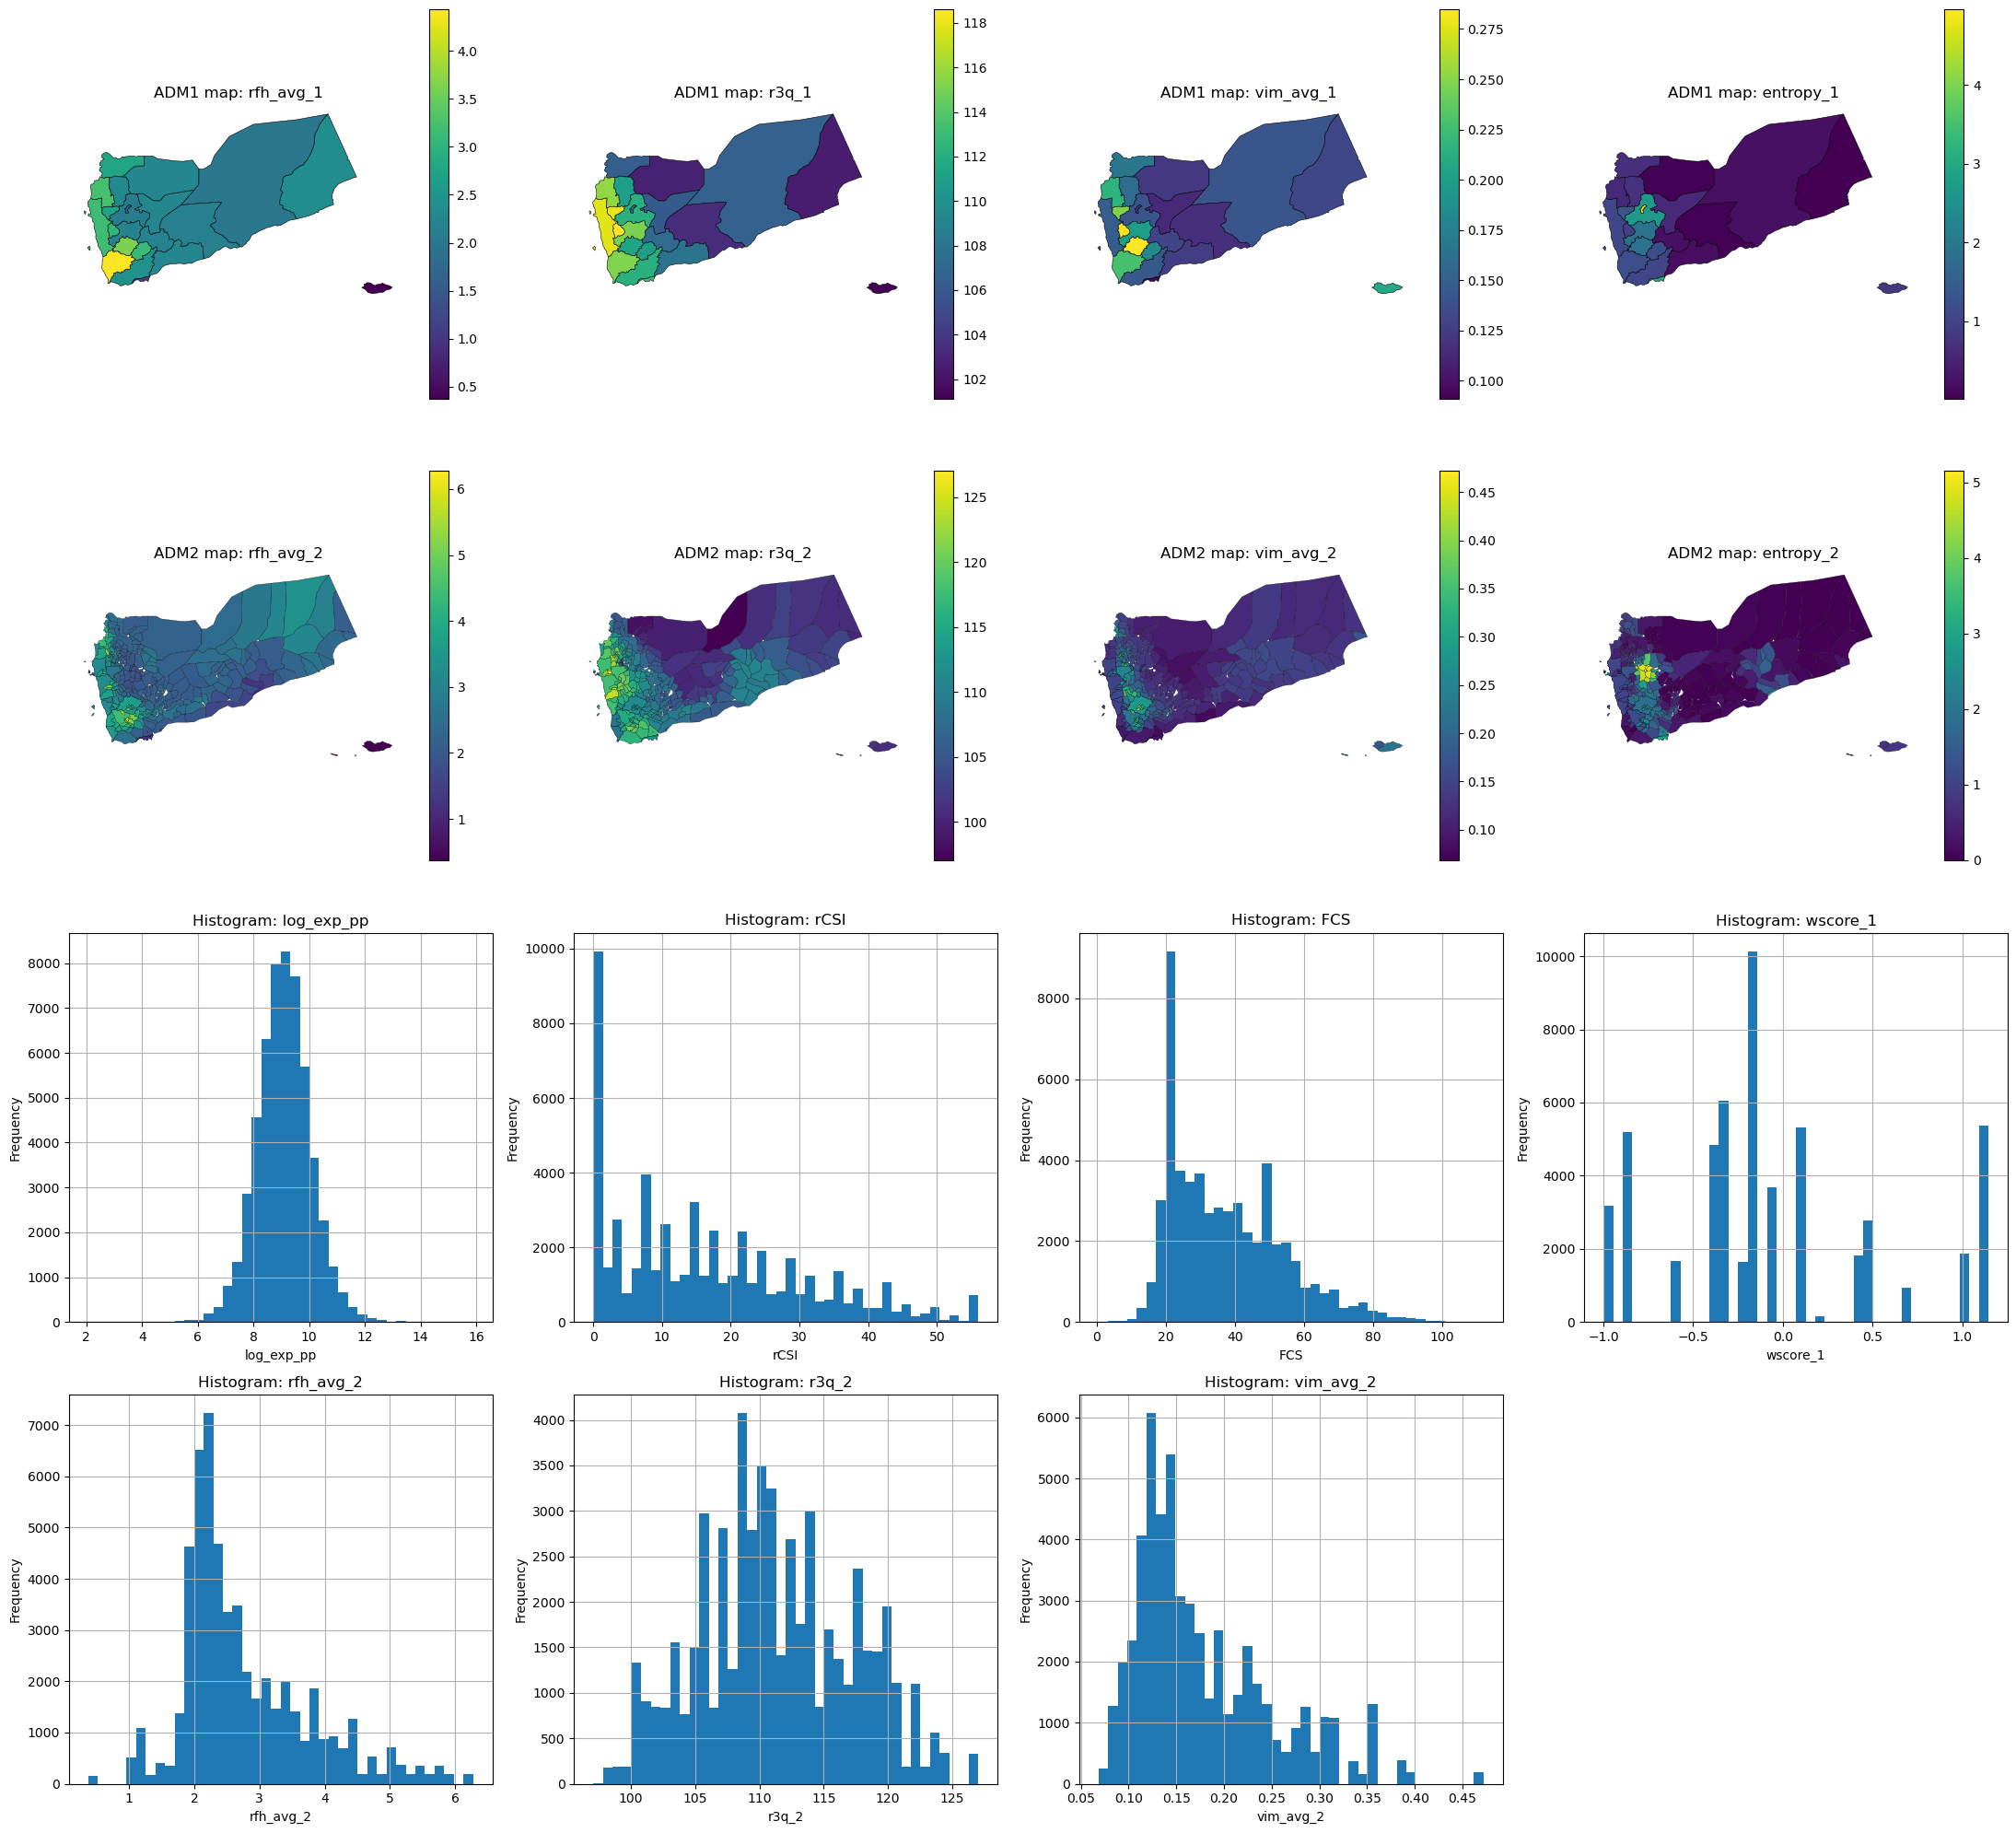

In [99]:
# One unique figure with:
# Row 1: ADM1 maps
# Row 2: ADM2 maps
# Then histograms below

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt
from shapely.geometry.base import BaseGeometry

plot_df = df_clean.copy()

# Convert WKT geometries back to shapely geometries if needed
for geom_col in ["adm1geometry", "adm2geometry"]:
    if geom_col in plot_df.columns:
        plot_df[geom_col] = plot_df[geom_col].apply(
            lambda x: wkt.loads(x) if isinstance(x, str) else x
        )

# Variables to plot
adm1_map_vars = ["rfh_avg_1", "r3q_1", "vim_avg_1","entropy_1"]
adm2_map_vars = ["rfh_avg_2", "r3q_2", "vim_avg_2","entropy_2"]

hist_vars = [
    "log_exp_pp",
    "rCSI",
    "FCS",
    "FES_eqiv",
    "wscore_1",
    "rfh_avg_2",
    "r3q_2",
    "vim_avg_2",
]

adm1_map_vars = [c for c in adm1_map_vars if c in plot_df.columns]
adm2_map_vars = [c for c in adm2_map_vars if c in plot_df.columns]
hist_vars = [c for c in hist_vars if c in plot_df.columns]

# Build ADM1 GeoDataFrame
adm1_gdf = (
    plot_df[["adm1name", "adm1code", "adm1geometry"] + adm1_map_vars]
    .drop_duplicates(subset=["adm1code"])
    .dropna(subset=["adm1geometry"])
    .copy()
)

adm1_gdf = gpd.GeoDataFrame(
    adm1_gdf,
    geometry="adm1geometry",
    crs="EPSG:4326"
)

# Build ADM2 GeoDataFrame
adm2_gdf = (
    plot_df[["adm2name", "adm2code", "adm2geometry"] + adm2_map_vars]
    .drop_duplicates(subset=["adm2code"])
    .dropna(subset=["adm2geometry"])
    .copy()
)

adm2_gdf = gpd.GeoDataFrame(
    adm2_gdf,
    geometry="adm2geometry",
    crs="EPSG:4326"
)

# Create layout
n_map_cols = 4
n_hist_cols = 4
n_hist_rows = int(np.ceil(len(hist_vars) / n_hist_cols))

total_rows = 2 + n_hist_rows
total_cols = 4

fig, axes = plt.subplots(
    total_rows,
    total_cols,
    figsize=(22, 5 * total_rows)
)

axes = np.array(axes).reshape(total_rows, total_cols)

# Turn all axes off first
for ax in axes.ravel():
    ax.axis("off")

# Row 1 — ADM1 maps
for i, col in enumerate(adm1_map_vars):
    ax = axes[0, i]
    adm1_gdf.plot(
        column=col,
        ax=ax,
        legend=True,
        edgecolor="black",
        linewidth=0.4
    )
    ax.set_title(f"ADM1 map: {col}")
    ax.axis("off")

# Row 2 — ADM2 maps
for i, col in enumerate(adm2_map_vars):
    ax = axes[1, i]
    adm2_gdf.plot(
        column=col,
        ax=ax,
        legend=True,
        edgecolor="black",
        linewidth=0.2
    )
    ax.set_title(f"ADM2 map: {col}")
    ax.axis("off")

# Histogram rows
for i, col in enumerate(hist_vars):
    row = 2 + (i // n_hist_cols)
    col_pos = i % n_hist_cols

    ax = axes[row, col_pos]
    ax.axis("on")

    plot_df[col].dropna().hist(bins=40, ax=ax)
    ax.set_title(f"Histogram: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()

FIG_PATH = BASE_OUT / "maps_and_histograms.png"
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")

print("Saved figure to:")
print(FIG_PATH)

plt.show()